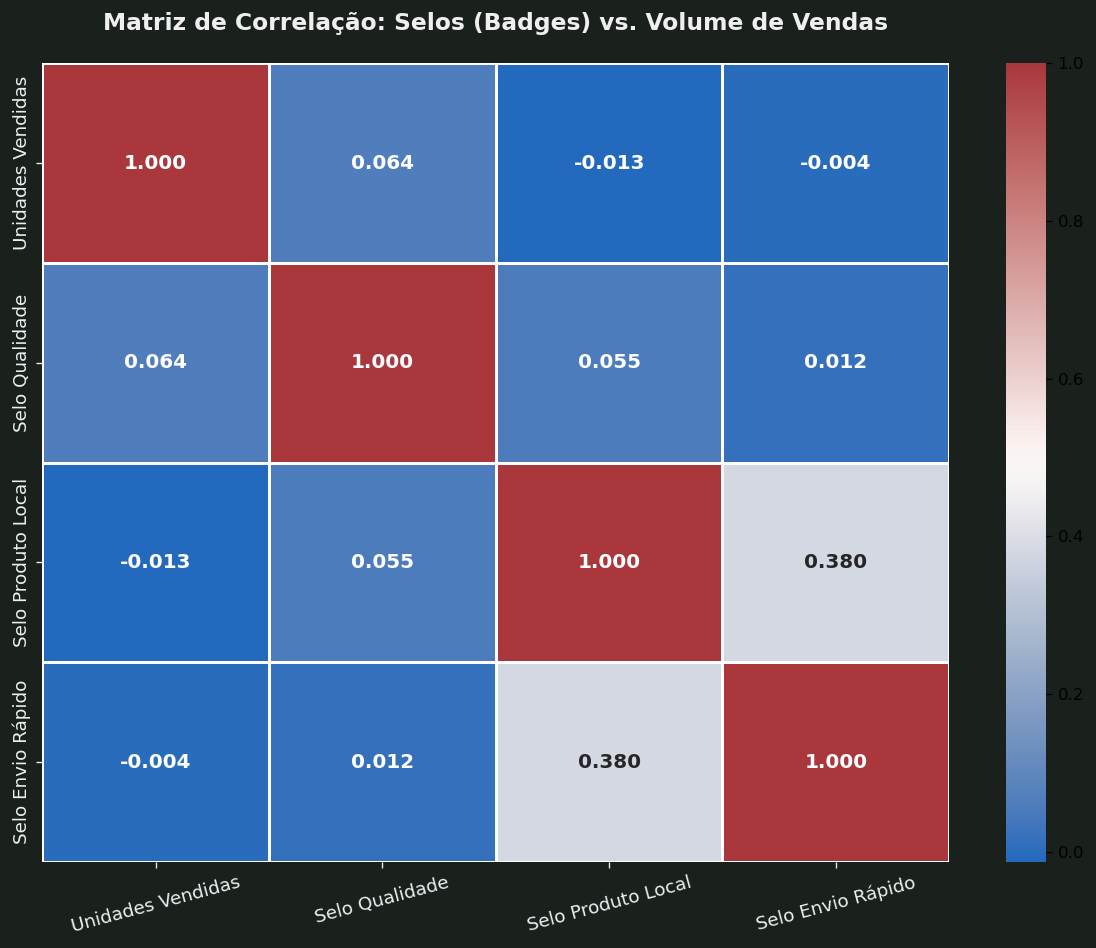

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def gerar_matriz_badges(caminho_csv):
    # 1. Carga e tratamento rápido dos tipos de dados
    df = pd.read_csv(caminho_csv)
    df['units_sold_pure'] = pd.to_numeric(df['units_sold'], errors='coerce')
    
    badge_cols = ['badge_product_qualityFix', 'badge_local_productFix', 'badge_fast_shippingFix']
    for col in badge_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
        
    # 2. Isolamento e renomeação para apresentação executiva
    corr_data = df[['units_sold_pure'] + badge_cols].copy()
    corr_data.columns = ['Unidades Vendidas', 'Selo Qualidade', 'Selo Produto Local', 'Selo Envio Rápido']
    
    # 3. Construção do Painel Visual
    cor_fundo_slide = '#1A211D'
    fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
    fig.patch.set_facecolor(cor_fundo_slide)
    ax.set_facecolor(cor_fundo_slide)
    
    sns.heatmap(
        corr_data.corr(), 
        annot=True, 
        cmap='vlag', 
        fmt=".3f", 
        linewidths=1.5, 
        ax=ax,
        annot_kws={"size": 12, "weight": "bold"}
    )
    
    ax.set_title("Matriz de Correlação: Selos (Badges) vs. Volume de Vendas", color='#EFEFEF', fontsize=14, pad=20, weight='bold')
    ax.tick_params(colors='#EFEFEF', labelsize=11)
    plt.xticks(rotation=15)
    
    plt.tight_layout()
    plt.savefig('matriz_correlacao_badges.png', facecolor='#1A211D')
    plt.show()

if __name__ == "__main__":
    gerar_matriz_badges('../../../Datasets/limpos_final_csv.csv')

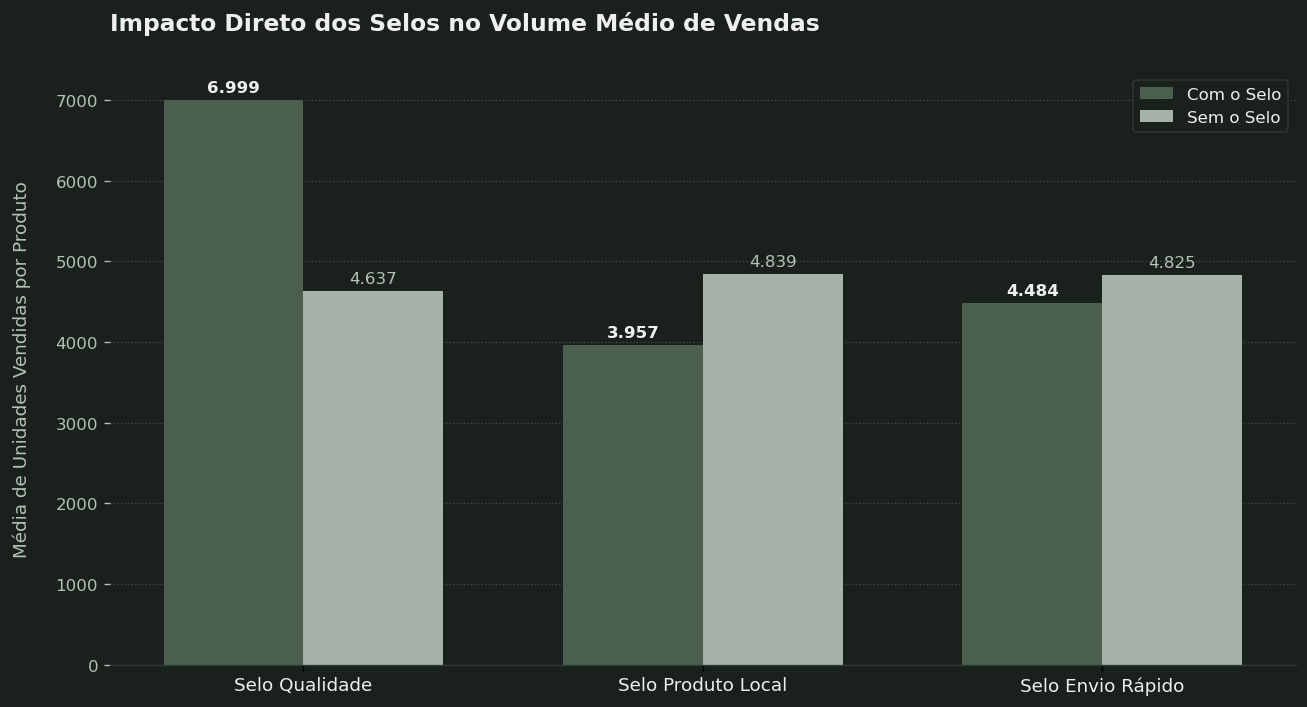

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Garantir o carregamento do DataFrame (Mantendo a tua estrutura original)
if 'limpos_df' not in globals():
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    limpos_df = limpos[list(limpos.keys())[0]]

# Tratamento e conversão de tipos
limpos_df['rating_num'] = pd.to_numeric(limpos_df['rating'], errors='coerce')
limpos_df['units_sold_pure'] = pd.to_numeric(limpos_df['units_sold'], errors='coerce')

# Filtragem de registros consistentes
df_validos = limpos_df[
    (limpos_df['rating_num'] >= 1) & (limpos_df['rating_num'] <= 5) & 
    (limpos_df['units_sold_pure'].notna())
].copy()

# 2. Cálculo do Impacto Individual de cada Badge
badges = {
    'Selo Qualidade': 'badge_product_qualityFix',
    'Selo Produto Local': 'badge_local_productFix',
    'Selo Envio Rápido': 'badge_fast_shippingFix'
}

categorias_grafico = []
medias_com_selo = []
medias_sem_selo = []

for label, col in badges.items():
    # Forçar conversão para booleano/numérico para evitar erros de tipo
    df_validos[col] = pd.to_numeric(df_validos[col], errors='coerce').fillna(0).astype(bool)
    
    media_com = df_validos[df_validos[col] == True]['units_sold_pure'].mean()
    media_sem = df_validos[df_validos[col] == False]['units_sold_pure'].mean()
    
    categorias_grafico.append(label)
    medias_com_selo.append(media_com)
    medias_sem_selo.append(media_sem)

# 3. Construção do Gráfico de Barras Comparativo (Estilo Slide Dark)
cor_fundo_slide = '#1A211D'
fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
fig.patch.set_facecolor(cor_fundo_slide)
ax.set_facecolor(cor_fundo_slide)

x = np.arange(len(categorias_grafico))
largura_barra = 0.35

# Plotagem das barras corrigida
barra_com = ax.bar(x - largura_barra/2, list(map(int, medias_com_selo)), largura_barra, label='Com o Selo', color='#4B5F4F')
barra_sem = ax.bar(x + largura_barra/2, list(map(int, medias_sem_selo)), largura_barra, label='Sem o Selo', color='#A6B3A9')

# Adicionar os valores exatos em cima das barras para facilitar a leitura
for bar in barra_com:
    height = bar.get_height()
    ax.annotate(f'{height:,}'.replace(',', '.'),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', color='#EFEFEF', fontsize=10, weight='bold')

for bar in barra_sem:
    height = bar.get_height()
    ax.annotate(f'{height:,}'.replace(',', '.'),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', color='#B2C2B7', fontsize=10)

# Customização de Eixos e Títulos (Padrão Dark)
ax.set_title('Impacto Direto dos Selos no Volume Médio de Vendas', color='#EFEFEF', fontsize=14, pad=25, weight='bold', loc='left')
ax.set_ylabel('Média de Unidades Vendidas por Produto', color='#B2C2B7', fontsize=11, labelpad=15)
ax.set_xticks(x)
ax.set_xticklabels(categorias_grafico, color='#EFEFEF', fontsize=11)
ax.tick_params(axis='y', colors='#B2C2B7')

# Grid sutil de fundo apenas no eixo Y
ax.grid(axis='y', linestyle=':', alpha=0.2, color='#EFEFEF')
ax.set_axisbelow(True)

# Legenda estilizada
legend = ax.legend(facecolor=cor_fundo_slide, edgecolor='#2E3B34', labelcolor='#EFEFEF', loc='upper right')

# Remover bordas desnecessárias
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#2E3B34')

plt.tight_layout()
plt.savefig('impacto_direto_badges.png', facecolor=cor_fundo_slide)
plt.show()

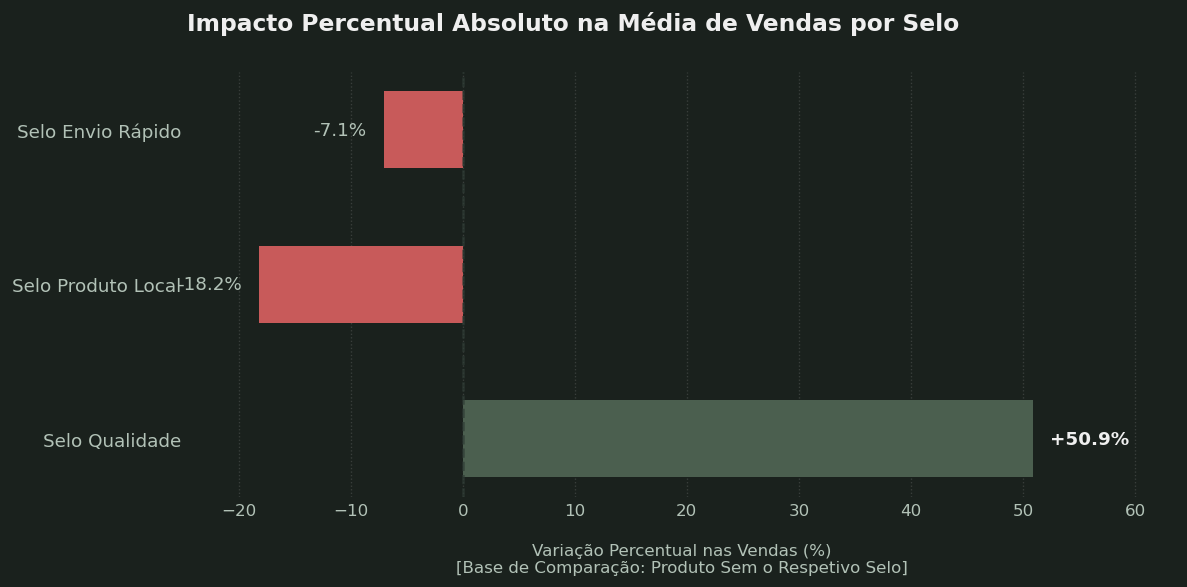

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcular a variação percentual exata entre ter e não ter o selo
# Fórmula: ((Com Selo - Sem Selo) / Sem Selo) * 100
variacoes_percentuais = []
for com, sem in zip(medias_com_selo, medias_sem_selo):
    var_pct = ((com - sem) / sem) * 100
    variacoes_percentuais.append(var_pct)

# 2. Configuração do Gráfico de Barras Horizontais (Estilo Slide Dark)
cor_fundo_slide = '#1A211D'
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
fig.patch.set_facecolor(cor_fundo_slide)
ax.set_facecolor(cor_fundo_slide)

y_pos = np.arange(len(categorias_grafico))

# Definição de cores baseada no impacto (Verde para ganho, Vermelho/Alerta para perda)
cores_impacto = ['#4B5F4F' if v >= 0 else '#C85A5A' for v in variacoes_percentuais]

# Plotagem das barras horizontais
barras = ax.barh(y_pos, variacoes_percentuais, height=0.5, color=cores_impacto, edgecolor='none')

# 3. Adicionar os rótulos de % diretamente nas pontas das barras
for bar, valor in zip(barras, variacoes_percentuais):
    width = bar.get_width()
    # Se o valor for positivo, coloca o texto à direita da barra. Se for negativo, coloca à esquerda.
    posicao_x = width + 1.5 if valor >= 0 else width - 1.5
    alinhamento_h = 'left' if valor >= 0 else 'right'
    
    # Destaca o campeão em Bold
    peso_fonte = 'bold' if valor > 40 else 'normal'
    cor_fonte = '#EFEFEF' if valor >= 0 else '#B2C2B7'
    
    ax.annotate(f'{valor:+.1f}%',
                xy=(posicao_x, bar.get_y() + bar.get_height() / 2),
                xytext=(0, 0), textcoords="offset points",
                ha=alinhamento_h, va='center', 
                color=cor_fonte, fontsize=11, weight=peso_fonte)

# 4. Customização Executiva do Layout
ax.set_title('Impacto Percentual Absoluto na Média de Vendas por Selo', color='#EFEFEF', fontsize=14, pad=25, weight='bold', loc='left')
ax.set_yticks(y_pos)
ax.set_yticklabels(categorias_grafico, color='#EFEFEF', fontsize=11)
ax.set_xlabel('Variação Percentual nas Vendas (%)\n[Base de Comparação: Produto Sem o Respetivo Selo]', color='#B2C2B7', fontsize=10, labelpad=15)

# Adicionar uma linha vertical tracejada no ponto ZERO para marcar o balanço
ax.axvline(0, color='#2E3B34', linestyle='--', linewidth=1.5, alpha=0.7)

# Ajustar limites do eixo X para dar folga para os textos das percentagens
limite_max = max(variacoes_percentuais) * 1.25
limite_min = min(variacoes_percentuais) * 1.35
ax.set_xlim(limite_min, limite_max)

# Remover os traços (ticks) e bordas para um visual minimalista e moderno
ax.tick_params(axis='both', which='both', length=0, colors='#B2C2B7')
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Grid sutil vertical para ajudar a acompanhar a escala de percentagem
ax.grid(axis='x', linestyle=':', alpha=0.15, color='#EFEFEF')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('variacao_percentual_badges.png', facecolor=cor_fundo_slide)
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=acb13dac-3e3d-49c3-81b9-b25c403473b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>